# HW12 – временные ряды: temporal split, baseline-модели и GRU

В этой работе:
- загружаем `S12-hw-dataset.csv`;
- делаем корректный `train / validation / test` **по времени**;
- строим baseline-подходы `B1`, `B2`, `B3`;
- обучаем `R1` = `GRU` на оконном представлении ряда;
- выбираем лучший подход по `validation`;
- только один раз оцениваем лучший вариант на `test`;
- сохраняем артефакты в `artifacts/`.

In [45]:
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [46]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"device: {device}")
print(f"torch: {torch.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

device: cpu
torch: 2.10.0+cpu
pandas: 3.0.1
numpy: 2.4.3


In [47]:
DATA_PATH = Path("S12-hw-dataset.csv")

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Данные и первичный анализ

По требованиям домашней работы нужно:
- загрузить CSV;
- привести `date` к `datetime`;
- отсортировать строки по времени;
- показать размер датасета, диапазон дат, пропуски и базовый график ряда.

In [48]:
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

if "target" not in df.columns:
    raise ValueError("В датасете должна быть колонка 'target'.")

print("Первые строки:")
display(df.head())

print("\nЧисло наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "—", df["date"].max())

print("\nПропуски по колонкам:")
display(df.isna().sum())

print("\nШаг времени:")
display(df["date"].diff().dropna().value_counts().head())

Первые строки:


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62



Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:


date      0
target    0
dtype: int64


Шаг времени:


date
0 days 01:00:00    4319
Name: count, dtype: int64

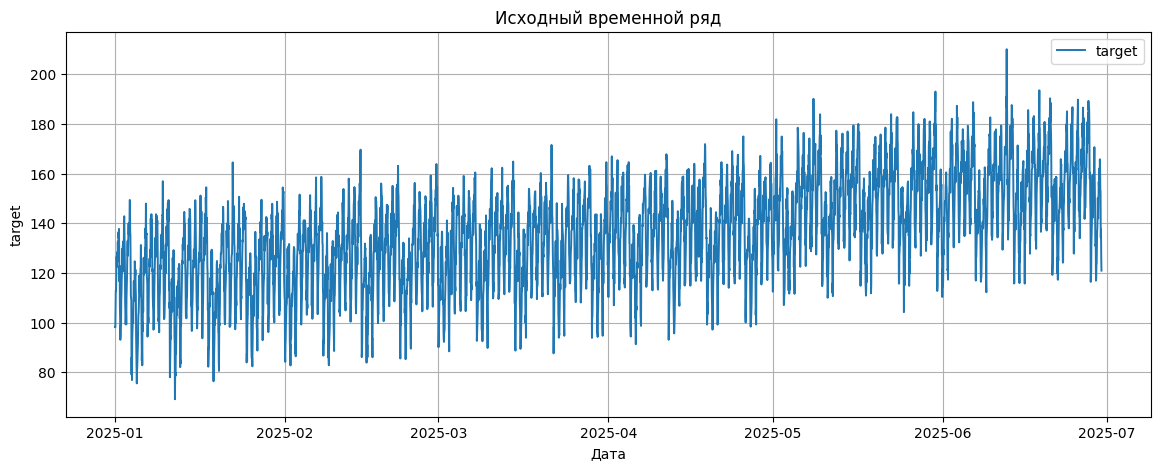

In [49]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.4, label="target")
ax.set_title("Исходный временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.show()

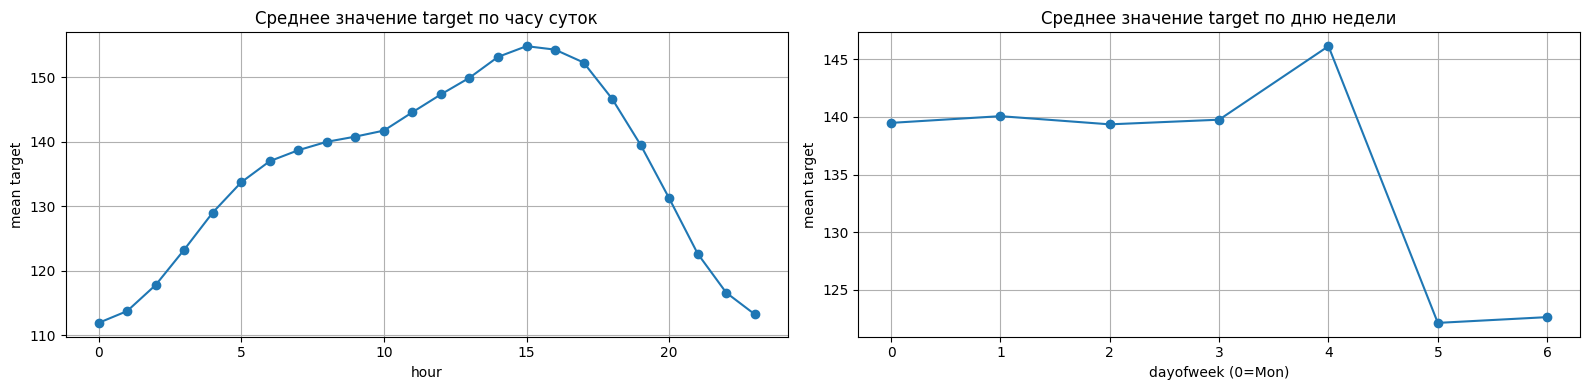

In [50]:
eda = df.copy()
eda["hour"] = eda["date"].dt.hour
eda["dayofweek"] = eda["date"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

hour_profile = eda.groupby("hour")["target"].mean()
axes[0].plot(hour_profile.index, hour_profile.values, marker="o")
axes[0].set_title("Среднее значение target по часу суток")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("mean target")

dow_profile = eda.groupby("dayofweek")["target"].mean()
axes[1].plot(dow_profile.index, dow_profile.values, marker="o")
axes[1].set_title("Среднее значение target по дню недели")
axes[1].set_xlabel("dayofweek (0=Mon)")
axes[1].set_ylabel("mean target")

plt.tight_layout()
plt.show()

## 2. Корректный temporal split

Для временного ряда `random split` использовать нельзя:
модель должна учиться на прошлом и проверяться на будущем.

Поэтому делаем:
- `train` — ранняя часть ряда,
- `validation` — следующий участок,
- `test` — самый поздний участок.

In [51]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15


def temporal_split(data: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    total = len(data)
    assert abs(cfg.train_frac + cfg.val_frac + cfg.test_frac - 1.0) < 1e-9

    train_end = int(total * cfg.train_frac)
    val_end = int(total * (cfg.train_frac + cfg.val_frac))

    train_df = data.iloc[:train_end].copy()
    val_df = data.iloc[train_end:val_end].copy()
    test_df = data.iloc[val_end:].copy()

    return train_df, val_df, test_df


split_cfg = SplitConfig(train_frac=0.70, val_frac=0.15, test_frac=0.15)
train_df, val_df, test_df = temporal_split(df, split_cfg)

print("Размеры частей:")
print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)

print("\nГраницы split:")
print("train:", train_df["date"].min(), "—", train_df["date"].max())
print("validation:", val_df["date"].min(), "—", val_df["date"].max())
print("test:", test_df["date"].min(), "—", test_df["date"].max())

split_summary = (
    f"train[{train_df['date'].min()}..{train_df['date'].max()}], "
    f"val[{val_df['date'].min()}..{val_df['date'].max()}], "
    f"test[{test_df['date'].min()}..{test_df['date'].max()}]"
)
print("\nsplit_summary:")
print(split_summary)

Размеры частей:
train: (3024, 2)
validation: (648, 2)
test: (648, 2)

Границы split:
train: 2025-01-01 00:00:00 — 2025-05-06 23:00:00
validation: 2025-05-07 00:00:00 — 2025-06-02 23:00:00
test: 2025-06-03 00:00:00 — 2025-06-29 23:00:00

split_summary:
train[2025-01-01 00:00:00..2025-05-06 23:00:00], val[2025-05-07 00:00:00..2025-06-02 23:00:00], test[2025-06-03 00:00:00..2025-06-29 23:00:00]


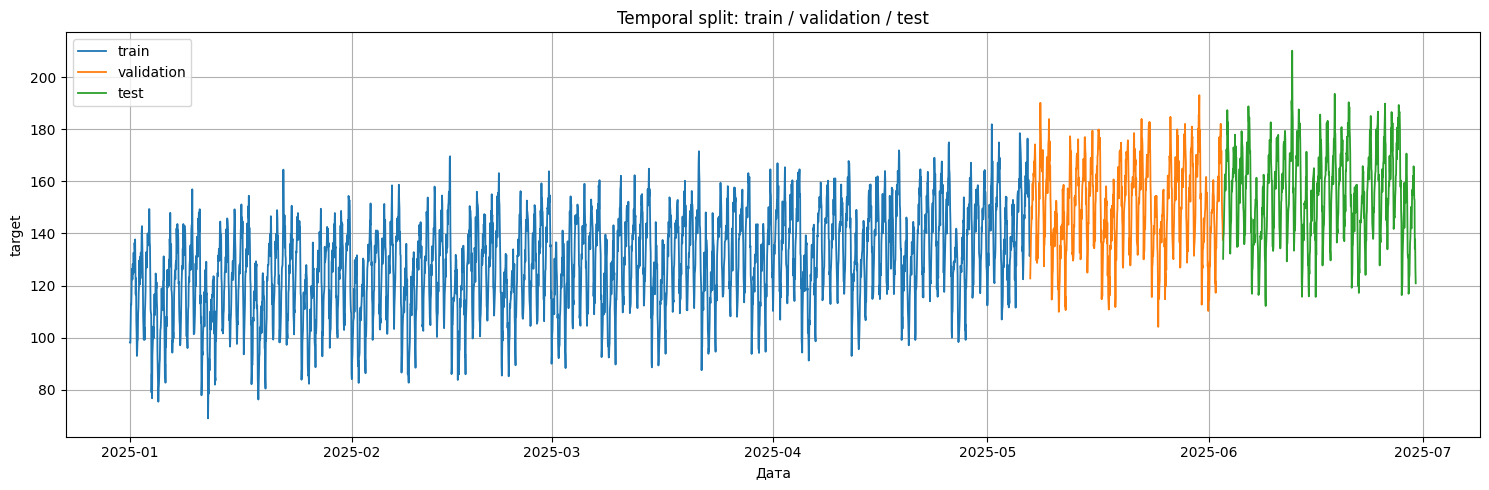

In [52]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(train_df["date"], train_df["target"], label="train", lw=1.3)
ax.plot(val_df["date"], val_df["target"], label="validation", lw=1.3)
ax.plot(test_df["date"], test_df["target"], label="test", lw=1.3)

ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Признаки для baseline-моделей

Минимум по требованиям домашки:
- `lag_1`
- `lag_7`
- `lag_14`
- `rolling_mean_7`
- `rolling_std_7`
- календарные признаки из даты

Дополнительно для почасового ряда разумно добавить:
- `lag_24`
- `lag_168`
- `rolling_mean_24`
- `rolling_std_24`
- `hour`

In [53]:
def add_calendar_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["dayofweek"] = out["date"].dt.dayofweek
    out["hour"] = out["date"].dt.hour
    out["day"] = out["date"].dt.day
    out["month"] = out["date"].dt.month
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    return out


def add_lag_rolling_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # Обязательные признаки
    out["lag_1"] = out["target"].shift(1)
    out["lag_7"] = out["target"].shift(7)
    out["lag_14"] = out["target"].shift(14)

    out["rolling_mean_7"] = out["target"].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out["target"].shift(1).rolling(window=7).std()

    # Дополнительные признаки для почасового ряда
    out["lag_24"] = out["target"].shift(24)
    out["lag_168"] = out["target"].shift(168)
    out["rolling_mean_24"] = out["target"].shift(1).rolling(window=24).mean()
    out["rolling_std_24"] = out["target"].shift(1).rolling(window=24).std()

    return out


features_df = add_calendar_features(df)
features_df = add_lag_rolling_features(features_df)

print("Пропуски после построения признаков:")
display(features_df.isna().sum()[features_df.isna().sum() > 0])

Пропуски после построения признаков:


lag_1                1
lag_7                7
lag_14              14
rolling_mean_7       7
rolling_std_7        7
lag_24              24
lag_168            168
rolling_mean_24     24
rolling_std_24      24
dtype: int64

In [54]:
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "lag_24", "lag_168",
    "rolling_mean_24", "rolling_std_24",
    "dayofweek", "hour", "day", "month", "is_weekend"
]

model_df = features_df.dropna().reset_index(drop=True)

train_feat_df = model_df[model_df["date"] <= train_df["date"].max()].copy()
val_feat_df = model_df[
    (model_df["date"] >= val_df["date"].min()) &
    (model_df["date"] <= val_df["date"].max())
].copy()
test_feat_df = model_df[model_df["date"] >= test_df["date"].min()].copy()

print("train_feat_df:", train_feat_df.shape)
print("val_feat_df:", val_feat_df.shape)
print("test_feat_df:", test_feat_df.shape)

display(model_df.head())

train_feat_df: (2856, 16)
val_feat_df: (648, 16)
test_feat_df: (648, 16)


,date,target,dayofweek,hour,day,month,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2025-01-08 00:00:00,97.11,2,0,8,1,0,104.82,141.22,129.36,120.507143,14.492322,98.53,98.14,122.167500,14.110294
1,2025-01-08 01:00:00,97.44,2,1,8,1,0,97.11,137.81,126.26,114.205714,13.543831,102.16,98.07,122.108333,14.216298
2,2025-01-08 02:00:00,101.13,2,2,8,1,0,97.44,120.70,141.90,108.438571,9.930756,99.82,104.70,121.911667,14.533371
3,2025-01-08 03:00:00,106.67,2,3,8,1,0,101.13,121.47,138.13,105.642857,8.564266,104.86,112.81,121.966250,14.449009
4,2025-01-08 04:00:00,114.46,2,4,8,1,0,106.67,110.88,132.69,103.528571,5.153398,116.19,112.62,122.041667,14.360292


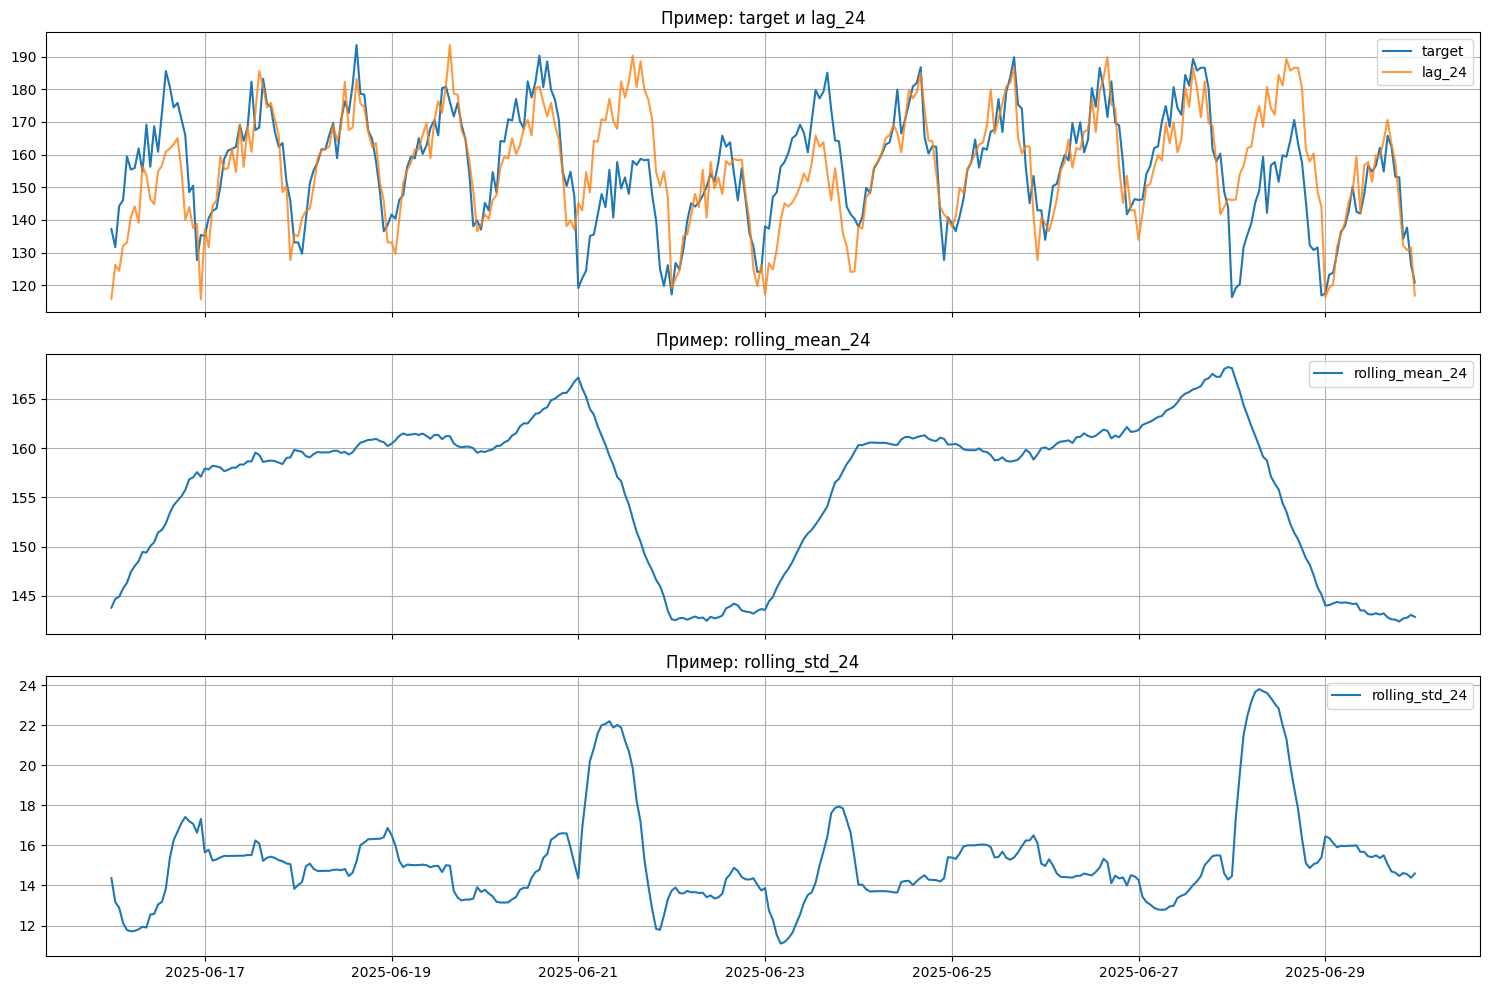

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

plot_part = model_df.tail(24 * 14).copy()

axes[0].plot(plot_part["date"], plot_part["target"], label="target")
axes[0].plot(plot_part["date"], plot_part["lag_24"], label="lag_24", alpha=0.8)
axes[0].set_title("Пример: target и lag_24")
axes[0].legend()

axes[1].plot(plot_part["date"], plot_part["rolling_mean_24"], label="rolling_mean_24")
axes[1].set_title("Пример: rolling_mean_24")
axes[1].legend()

axes[2].plot(plot_part["date"], plot_part["rolling_std_24"], label="rolling_std_24")
axes[2].set_title("Пример: rolling_std_24")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_examples.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0


def smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return 200.0 * np.mean(np.abs(y_true - y_pred) / denom)


def regression_metrics(y_true, y_pred) -> dict:
    return {
        "mae": mae(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }

## 4. Baseline-эксперименты

Обязательные эксперименты:
- `B1` — `naive-last`
- `B2` — `moving-average`
- `B3` — `ridge-lag-features`

Все результаты потом сохраняем в `artifacts/runs.csv`.

In [57]:
def make_run_row(
    experiment_id: str,
    dataset_name: str,
    model_summary: str,
    features_summary: str,
    scaler_name: str = "",
    optimizer_name: str = "",
    lr: float | str = "",
    window_size: int | str = "",
    horizon: int = 1,
    epochs_trained: int | str = "",
    notes: str = ""
):
    return {
        "experiment_id": experiment_id,
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler_name,
        "optimizer": optimizer_name,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": np.nan,
        "best_val_rmse": np.nan,
        "best_val_mape": np.nan,
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": notes,
    }


all_runs = []

In [58]:
# B2 — moving-average
MA_WINDOW = 24

b2_row = make_run_row(
    experiment_id="B2",
    dataset_name=DATA_PATH.name,
    model_summary=f"moving-average(window={MA_WINDOW})",
    features_summary=f"rolling mean of previous {MA_WINDOW} values",
    notes="prediction[t] = mean(target[t-window:t])"
)

val_pred_b2 = df["target"].shift(1).rolling(MA_WINDOW).mean().loc[val_df.index]
b2_val_metrics = regression_metrics(val_df["target"].values, val_pred_b2.values)

b2_row["best_val_mae"] = b2_val_metrics["mae"]
b2_row["best_val_rmse"] = b2_val_metrics["rmse"]
b2_row["best_val_mape"] = b2_val_metrics["mape"]

all_runs.append(b2_row)
print("B2 validation:", b2_val_metrics)

B2 validation: {'mae': 13.397980324074075, 'rmse': 16.169903600881327, 'mape': np.float64(9.198833855974383), 'smape': np.float64(8.994963266867636)}


In [59]:
# B3 — Ridge на лаговых и календарных признаках
X_train = train_feat_df[feature_cols].copy()
y_train = train_feat_df["target"].copy()

X_val = val_feat_df[feature_cols].copy()
y_val = val_feat_df["target"].copy()

ridge_scaler = StandardScaler()
X_train_scaled = ridge_scaler.fit_transform(X_train)
X_val_scaled = ridge_scaler.transform(X_val)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

val_pred_b3 = ridge_model.predict(X_val_scaled)
b3_val_metrics = regression_metrics(y_val.values, val_pred_b3)

b3_row = make_run_row(
    experiment_id="B3",
    dataset_name=DATA_PATH.name,
    model_summary="Ridge(alpha=1.0)",
    features_summary=", ".join(feature_cols),
    scaler_name="StandardScaler(X only, fit on train)",
    notes="Lag + rolling + calendar features; no future leakage"
)

b3_row["best_val_mae"] = b3_val_metrics["mae"]
b3_row["best_val_rmse"] = b3_val_metrics["rmse"]
b3_row["best_val_mape"] = b3_val_metrics["mape"]

all_runs.append(b3_row)
print("B3 validation:", b3_val_metrics)

B3 validation: {'mae': 5.03381677199161, 'rmse': 6.361672620512444, 'mape': np.float64(3.340954016276121), 'smape': np.float64(3.390461439244498)}


## 5. Оконное представление для GRU

По требованиям работы для `GRU` нужно:
- подготовить последовательности фиксированной длины `window_size`;
- реализовать `Dataset` / `DataLoader`;
- при масштабировании обучать scaler только на `train`.

In [60]:
WINDOW_SIZE = 48
HORIZON = 1
BATCH_SIZE = 128

series_all = df["target"].values.astype(np.float32).reshape(-1, 1)

train_size = len(train_df)
val_size = len(val_df)
test_size = len(test_df)

target_scaler = StandardScaler()
train_scaled = target_scaler.fit_transform(series_all[:train_size]).flatten()
val_scaled = target_scaler.transform(series_all[train_size:train_size + val_size]).flatten()
test_scaled = target_scaler.transform(series_all[train_size + val_size:]).flatten()

series_scaled_full = np.concatenate([train_scaled, val_scaled, test_scaled]).astype(np.float32)

In [61]:
def make_forecasting_windows(series_1d: np.ndarray, start_idx: int, end_idx: int, window_size: int):
    X, y, target_indices = [], [], []

    for target_idx in range(start_idx, end_idx):
        left = target_idx - window_size
        if left < 0:
            continue

        X.append(series_1d[left:target_idx])
        y.append(series_1d[target_idx])
        target_indices.append(target_idx)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    target_indices = np.asarray(target_indices, dtype=np.int64)
    return X, y, target_indices


train_start_idx = WINDOW_SIZE
train_end_idx = train_size

val_start_idx = train_size
val_end_idx = train_size + val_size

test_start_idx = train_size + val_size
test_end_idx = train_size + val_size + test_size

X_train_seq, y_train_seq, train_target_idx = make_forecasting_windows(
    series_scaled_full, train_start_idx, train_end_idx, WINDOW_SIZE
)
X_val_seq, y_val_seq, val_target_idx = make_forecasting_windows(
    series_scaled_full, val_start_idx, val_end_idx, WINDOW_SIZE
)
X_test_seq, y_test_seq, test_target_idx = make_forecasting_windows(
    series_scaled_full, test_start_idx, test_end_idx, WINDOW_SIZE
)

print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_val_seq:", X_val_seq.shape, "y_val_seq:", y_val_seq.shape)
print("X_test_seq:", X_test_seq.shape, "y_test_seq:", y_test_seq.shape)

X_train_seq: (2976, 48) y_train_seq: (2976,)
X_val_seq: (648, 48) y_val_seq: (648,)
X_test_seq: (648, 48) y_test_seq: (648,)


In [62]:
class ForecastDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(ForecastDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(ForecastDataset(X_val_seq, y_val_seq), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ForecastDataset(X_test_seq, y_test_seq), batch_size=BATCH_SIZE, shuffle=False)

In [63]:
class GRUForecast(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden)
        return pred

In [64]:
def inverse_target_scale(arr_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    arr_2d = np.asarray(arr_1d).reshape(-1, 1)
    return scaler.inverse_transform(arr_2d).ravel()


def evaluate_gru_model(model, loader, scaler, loss_fn):
    model.eval()

    losses = []
    preds_scaled = []
    targets_scaled = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            losses.append(loss.item())
            preds_scaled.append(pred.detach().cpu().numpy().ravel())
            targets_scaled.append(yb.detach().cpu().numpy().ravel())

    preds_scaled = np.concatenate(preds_scaled)
    targets_scaled = np.concatenate(targets_scaled)

    preds = inverse_target_scale(preds_scaled, scaler)
    targets = inverse_target_scale(targets_scaled, scaler)

    metrics = regression_metrics(targets, preds)
    metrics["loss"] = float(np.mean(losses))
    return metrics, preds, targets

In [65]:
def train_gru_model(
    model,
    train_loader,
    val_loader,
    scaler,
    optimizer,
    loss_fn,
    epochs: int = 25,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": [],
    }

    best_state = None
    best_val_mae = float("inf")
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_metrics, _, _ = evaluate_gru_model(model, val_loader, scaler, loss_fn)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_mape"].append(val_metrics["mape"])

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_MAE={val_metrics['mae']:.4f} | "
            f"val_RMSE={val_metrics['rmse']:.4f} | "
            f"val_MAPE={val_metrics['mape']:.4f}"
        )

    return history, best_state, best_epoch, best_val_mae

## 6. Эксперимент R1 — GRU

In [66]:
GRU_CONFIG = {
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "epochs": 25,
    "optimizer": "Adam",
    "loss": "MSELoss",
    "scaler": "StandardScaler(target only, fit on train)",
    "seed": SEED,
    "horizon": HORIZON,
}

gru_model = GRUForecast(
    input_size=GRU_CONFIG["input_size"],
    hidden_size=GRU_CONFIG["hidden_size"],
    num_layers=GRU_CONFIG["num_layers"],
    dropout=GRU_CONFIG["dropout"],
).to(device)

gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=GRU_CONFIG["lr"])
gru_loss_fn = nn.MSELoss()

gru_history, best_gru_state, best_gru_epoch, best_gru_val_mae = train_gru_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    scaler=target_scaler,
    optimizer=gru_optimizer,
    loss_fn=gru_loss_fn,
    epochs=GRU_CONFIG["epochs"],
)

Epoch 01 | train_loss=0.9920 | val_loss=1.6888 | val_MAE=20.2119 | val_RMSE=23.6738 | val_MAPE=12.7766
Epoch 02 | train_loss=0.6025 | val_loss=0.6917 | val_MAE=13.3810 | val_RMSE=15.6141 | val_MAPE=8.6540
Epoch 03 | train_loss=0.3744 | val_loss=0.3998 | val_MAE=10.0182 | val_RMSE=11.9886 | val_MAPE=6.4946
Epoch 04 | train_loss=0.2264 | val_loss=0.2040 | val_MAE=6.9140 | val_RMSE=8.6543 | val_MAPE=4.5810
Epoch 05 | train_loss=0.1945 | val_loss=0.1921 | val_MAE=6.8086 | val_RMSE=8.4072 | val_MAPE=4.5401
Epoch 06 | train_loss=0.1799 | val_loss=0.1911 | val_MAE=6.8104 | val_RMSE=8.3841 | val_MAPE=4.5351
Epoch 07 | train_loss=0.1730 | val_loss=0.1796 | val_MAE=6.5624 | val_RMSE=8.1203 | val_MAPE=4.3900
Epoch 08 | train_loss=0.1692 | val_loss=0.1768 | val_MAE=6.5028 | val_RMSE=8.0570 | val_MAPE=4.3563
Epoch 09 | train_loss=0.1657 | val_loss=0.1758 | val_MAE=6.4799 | val_RMSE=8.0346 | val_MAPE=4.3446
Epoch 10 | train_loss=0.1626 | val_loss=0.1754 | val_MAE=6.4718 | val_RMSE=8.0254 | val_MAPE=

In [67]:
best_gru_path = ARTIFACTS_DIR / "best_gru.pt"
torch.save(best_gru_state, best_gru_path)

best_gru_config = GRU_CONFIG | {
    "best_epoch": best_gru_epoch,
    "split_summary": split_summary,
    "dataset": DATA_PATH.name,
}

with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

gru_model.load_state_dict(best_gru_state)

r1_val_metrics, r1_val_preds, r1_val_targets = evaluate_gru_model(
    gru_model, val_loader, target_scaler, gru_loss_fn
)

r1_row = make_run_row(
    experiment_id="R1",
    dataset_name=DATA_PATH.name,
    model_summary=f"GRU(hidden_size={GRU_CONFIG['hidden_size']}, num_layers={GRU_CONFIG['num_layers']})",
    features_summary=f"windowed target only, window_size={WINDOW_SIZE}",
    scaler_name=GRU_CONFIG["scaler"],
    optimizer_name=GRU_CONFIG["optimizer"],
    lr=GRU_CONFIG["lr"],
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    epochs_trained=best_gru_epoch,
    notes="Best checkpoint selected by validation MAE"
)

r1_row["best_val_mae"] = r1_val_metrics["mae"]
r1_row["best_val_rmse"] = r1_val_metrics["rmse"]
r1_row["best_val_mape"] = r1_val_metrics["mape"]

all_runs.append(r1_row)

print("R1 validation:", r1_val_metrics)
print("best_gru saved to:", best_gru_path)

R1 validation: {'mae': 5.0882086753845215, 'rmse': 6.560711426188825, 'mape': np.float32(3.4479148), 'smape': np.float32(3.472119), 'loss': 0.12051780770222346}
best_gru saved to: artifacts\best_gru.pt


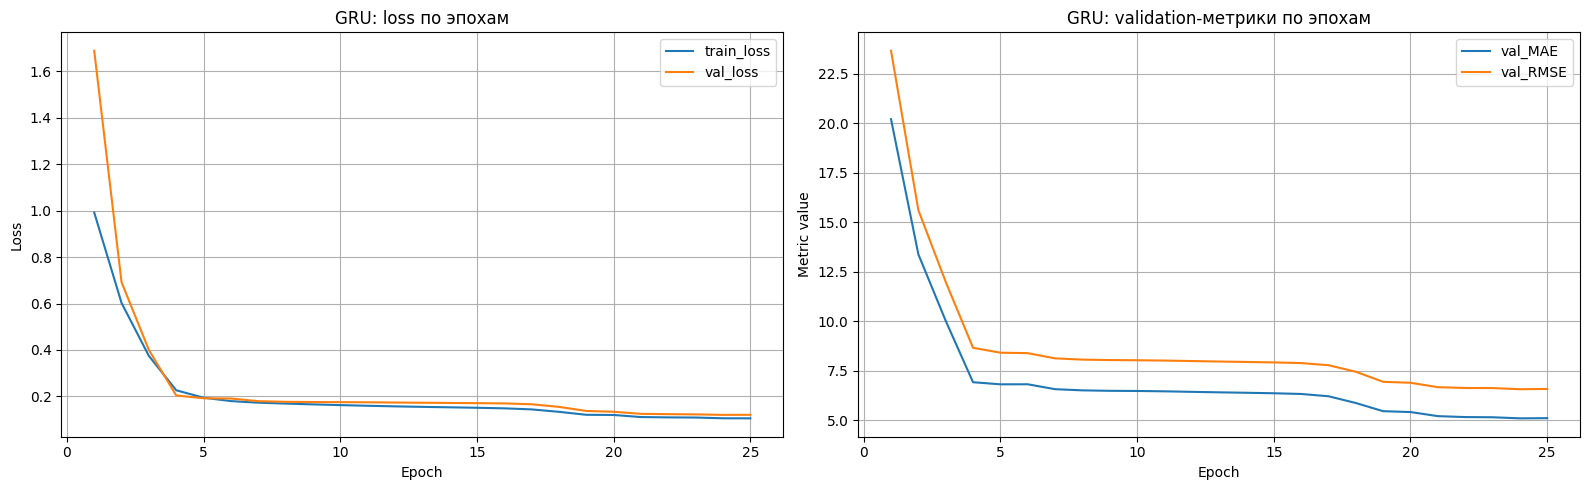

In [68]:
epochs_axis = np.arange(1, len(gru_history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs_axis, gru_history["train_loss"], label="train_loss")
axes[0].plot(epochs_axis, gru_history["val_loss"], label="val_loss")
axes[0].set_title("GRU: loss по эпохам")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_axis, gru_history["val_mae"], label="val_MAE")
axes[1].plot(epochs_axis, gru_history["val_rmse"], label="val_RMSE")
axes[1].set_title("GRU: validation-метрики по эпохам")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric value")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Сравнение всех подходов по validation

Лучшую модель выбираем **только по validation**.
`test` пока не используем.

,experiment_id,best_val_mae,best_val_rmse,best_val_mape
0,B2,13.397980,16.169904,9.198834
1,B3,5.033817,6.361673,3.340954
2,R1,5.088209,6.560711,3.447915


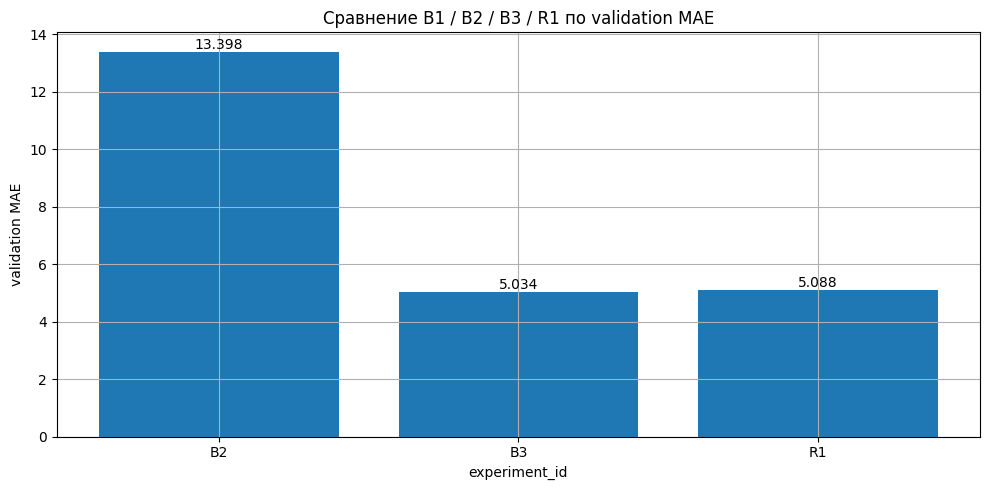

Лучшая модель по validation MAE: B3


In [69]:
runs_df = pd.DataFrame(all_runs).sort_values("experiment_id").reset_index(drop=True)
display(runs_df[["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape"]])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(runs_df["experiment_id"], runs_df["best_val_mae"])
ax.set_title("Сравнение B1 / B2 / B3 / R1 по validation MAE")
ax.set_xlabel("experiment_id")
ax.set_ylabel("validation MAE")

for i, v in enumerate(runs_df["best_val_mae"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()

best_experiment_id = runs_df.sort_values("best_val_mae").iloc[0]["experiment_id"]
print("Лучшая модель по validation MAE:", best_experiment_id)

## 8. Один финальный test только для лучшего подхода

Это обязательный принцип:
сначала выбираем победителя по `validation`,
и только потом один раз считаем `test`.

In [70]:
def evaluate_best_on_test(best_experiment_id: str):
    if best_experiment_id == "B1":
        test_pred = df["target"].shift(1).loc[test_df.index].values
        test_true = test_df["target"].values
        test_metrics = regression_metrics(test_true, test_pred)
        plot_dates = test_df["date"].values
        plot_true = test_true
        plot_pred = test_pred
        return test_metrics, plot_dates, plot_true, plot_pred

    if best_experiment_id == "B2":
        test_pred = df["target"].shift(1).rolling(MA_WINDOW).mean().loc[test_df.index].values
        test_true = test_df["target"].values
        test_metrics = regression_metrics(test_true, test_pred)
        plot_dates = test_df["date"].values
        plot_true = test_true
        plot_pred = test_pred
        return test_metrics, plot_dates, plot_true, plot_pred

    if best_experiment_id == "B3":
        X_test = test_feat_df[feature_cols].copy()
        y_test = test_feat_df["target"].values
        X_test_scaled = ridge_scaler.transform(X_test)
        test_pred = ridge_model.predict(X_test_scaled)
        test_metrics = regression_metrics(y_test, test_pred)
        plot_dates = test_feat_df["date"].values
        plot_true = y_test
        plot_pred = test_pred
        return test_metrics, plot_dates, plot_true, plot_pred

    if best_experiment_id == "R1":
        test_metrics, test_preds, test_targets = evaluate_gru_model(
            gru_model, test_loader, target_scaler, gru_loss_fn
        )
        plot_dates = df.iloc[test_target_idx]["date"].values
        plot_true = test_targets
        plot_pred = test_preds
        return test_metrics, plot_dates, plot_true, plot_pred

    raise ValueError(f"Неизвестный experiment_id: {best_experiment_id}")


best_test_metrics, best_plot_dates, best_plot_true, best_plot_pred = evaluate_best_on_test(best_experiment_id)

print("Test metrics for best model:")
print(best_test_metrics)

Test metrics for best model:
{'mae': 4.563510663664268, 'rmse': 5.805889129674163, 'mape': np.float64(2.9237882099773267), 'smape': np.float64(2.9549375651150656)}


In [71]:
best_mask = runs_df["experiment_id"] == best_experiment_id
runs_df.loc[best_mask, "test_mae"] = best_test_metrics["mae"]
runs_df.loc[best_mask, "test_rmse"] = best_test_metrics["rmse"]
runs_df.loc[best_mask, "test_mape"] = best_test_metrics["mape"]

runs_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_path, index=False)

print("runs.csv saved to:", runs_path)
display(runs_df)

runs.csv saved to: artifacts\runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B2,forecasting,S12-hw-dataset.csv,42,train[2025-01-01 00:00:00..2025-05-06 23:00:00...,,1,moving-average(window=24),rolling mean of previous 24 values,,,,,13.397980,16.169904,9.198834,NaN,NaN,NaN,prediction[t] = mean(target[t-window:t])
1,B3,forecasting,S12-hw-dataset.csv,42,train[2025-01-01 00:00:00..2025-05-06 23:00:00...,,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...","StandardScaler(X only, fit on train)",,,,5.033817,6.361673,3.340954,4.563511,5.805889,2.923788,Lag + rolling + calendar features; no future l...
2,R1,forecasting,S12-hw-dataset.csv,42,train[2025-01-01 00:00:00..2025-05-06 23:00:00...,48,1,"GRU(hidden_size=64, num_layers=1)","windowed target only, window_size=48","StandardScaler(target only, fit on train)",Adam,0.001,24,5.088209,6.560711,3.447915,NaN,NaN,NaN,Best checkpoint selected by validation MAE


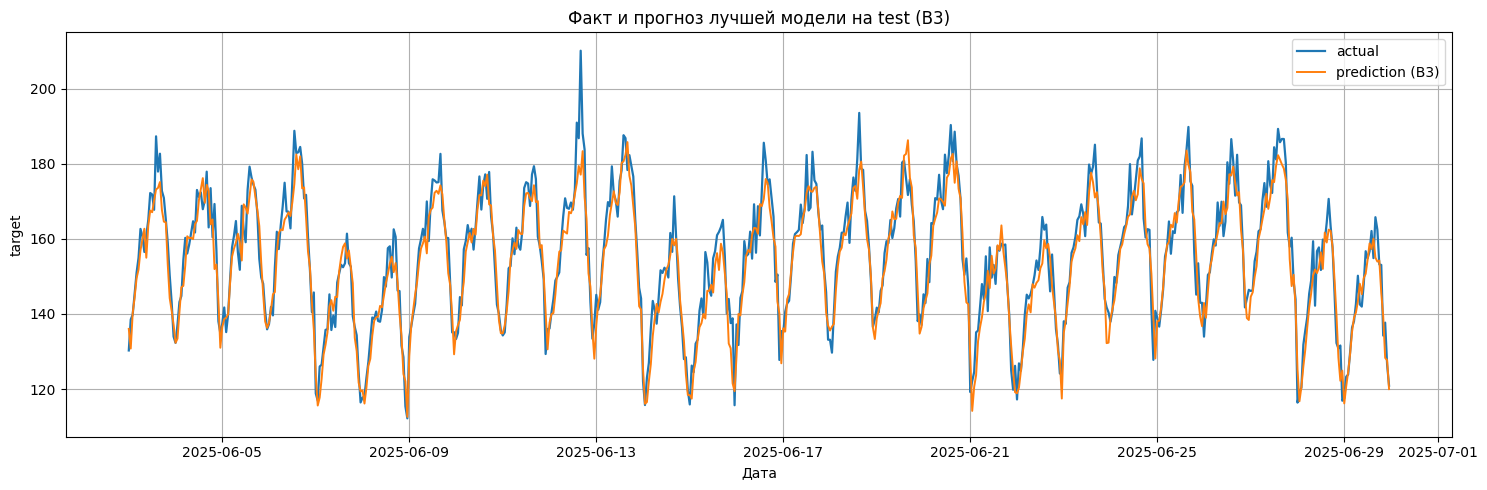

In [72]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(best_plot_dates, best_plot_true, label="actual", lw=1.6)
ax.plot(best_plot_dates, best_plot_pred, label=f"prediction ({best_experiment_id})", lw=1.4)

ax.set_title(f"Факт и прогноз лучшей модели на test ({best_experiment_id})")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()

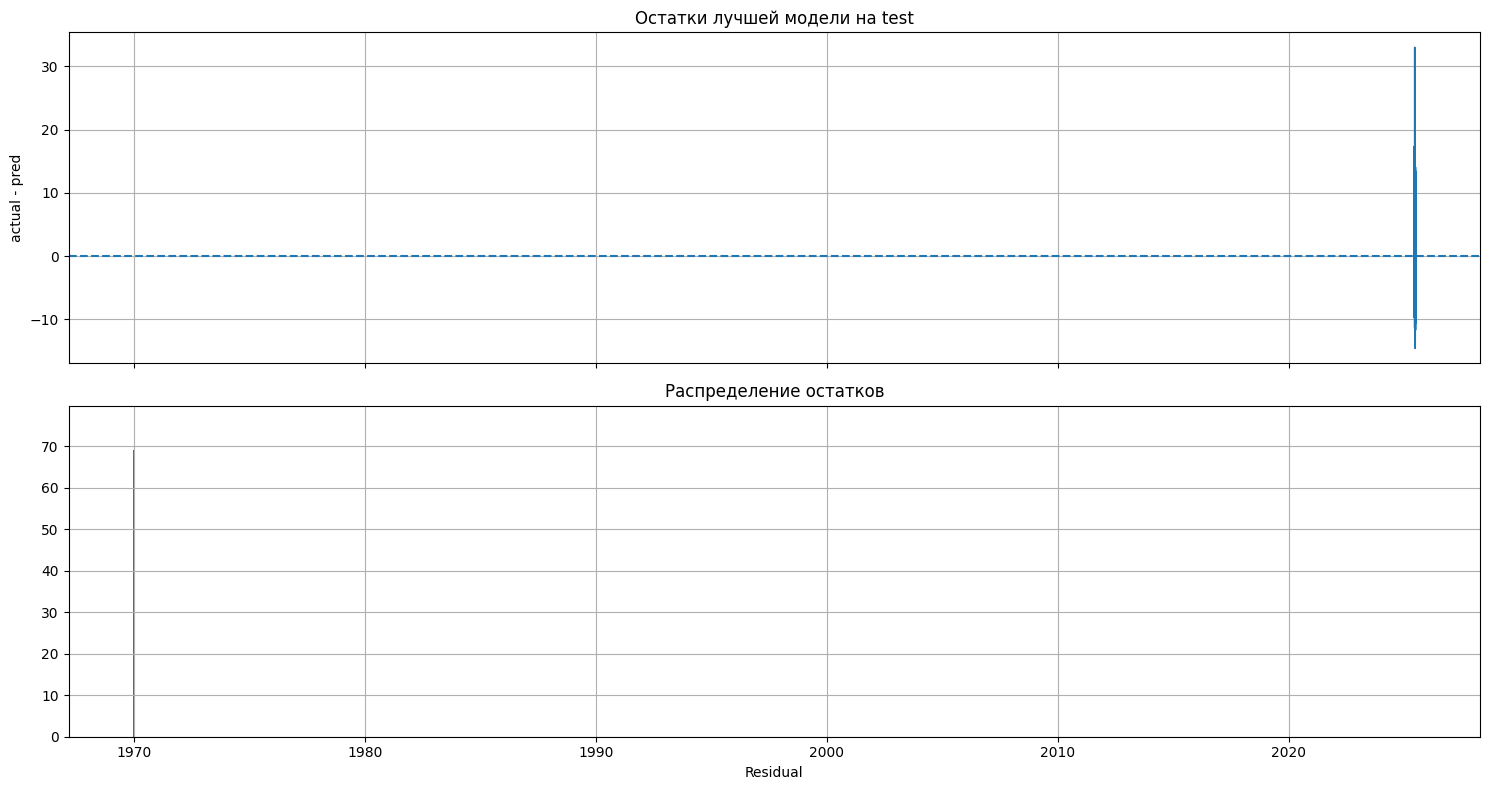

In [73]:
residuals = best_plot_true - best_plot_pred

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(best_plot_dates, residuals, lw=1.2)
axes[0].axhline(0.0, linestyle="--")
axes[0].set_title("Остатки лучшей модели на test")
axes[0].set_ylabel("actual - pred")

axes[1].hist(residuals, bins=30)
axes[1].set_title("Распределение остатков")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals_best.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Быстрая сводка для отчёта

In [74]:
best_baseline_row = runs_df[runs_df["experiment_id"].isin(["B1", "B2", "B3"])].sort_values("best_val_mae").iloc[0]
best_overall_row = runs_df.sort_values("best_val_mae").iloc[0]

print("Лучший baseline:", best_baseline_row["experiment_id"])
print("Лучшая модель overall:", best_overall_row["experiment_id"])
print()
print("best val MAE:", best_overall_row["best_val_mae"])
print("best val RMSE:", best_overall_row["best_val_rmse"])
print("best val MAPE:", best_overall_row["best_val_mape"])
print()
print("test MAE:", best_overall_row["test_mae"])
print("test RMSE:", best_overall_row["test_rmse"])
print("test MAPE:", best_overall_row["test_mape"])

Лучший baseline: B3
Лучшая модель overall: B3

best val MAE: 5.03381677199161
best val RMSE: 6.361672620512444
best val MAPE: 3.340954016276121

test MAE: 4.563510663664268
test RMSE: 5.805889129674163
test MAPE: 2.9237882099773267
